### Import packages

In [97]:
import pandas as pd
import numpy as np 
import fsspec
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Get the whole file from the website (da modificare)

In [ ]:
"""
files = fsspec.open_files(
    "hf://datasets/dmariaa70/METRAQ-Air-Quality/**/*.csv",
    expand=True
)

df = pd.concat(
    [pd.read_csv(f.open()) for f in files],
    ignore_index=True
)

df.head()
"""


## 1) Exploratory data analysis (EDA) 📝

We begin our analysis with Exploratory Data Analysis (EDA), a critical first step in understanding the dataset. This process helps reveal the structure of the data, identify unusual values, and uncover patterns using visual tools like graphs and charts. It also plays a key role in ensuring the data is clean and reliable for further analysis. 

### 1.1) Data Overview and Initial Inspection 📑

In [63]:
df_original = pd.read_csv("/Users/mmaggiora/Desktop/sample.csv", sep=";")

We create a copy of the original dataset (aeropolis_df_original) and assigned it to aeropolis_df to ensures that the original dataset remains unaltered during the analysis/modification process.

In [64]:
df = df_original.copy() 

In [4]:
df.head()

,sensor_id,sensor_name,utm_x,utm_y,magnitude_id,magnitude_name,entry_date,value,is_interpolated
0,28079008,Escuelas Aguirre,442117.2366,4474770.696,12,NOX,2006-08-16 01:00:00,56.000000,False
1,28079039,Barrio del Pilar,439689.0496,4481081.619,88,RS,2024-03-21 05:00:00,1.045836,True
2,28079057,Sanchinarro,444026.8080,4482820.581,1023,OC_IDW,2020-03-13 00:00:00,0.000000,False
3,28079049,Parque del Retiro,442095.5200,4473981.740,89,PRECIPITACION,2021-01-30 04:00:00,0.000000,True
4,28079060,Tres Olivos,441556.7005,4483543.994,1023,OC_IDW,2023-12-19 09:00:00,15.933061,False


We analyze the data dimensions by printing the number of rows and columns using the *.shape* function, which returns a tuple representing the dataset's shape.

In our case, the dataset contains 100,000 records with 10 features.

In [104]:
print(f"Number of rows and columns: {df.shape}")

Number of rows and columns: (100000, 10)


We now get the Column names, which is the list of all features in the dataset.

In [6]:
print(df.columns.tolist())

['sensor_id', 'sensor_name', 'utm_x', 'utm_y', 'magnitude_id', 'magnitude_name', 'entry_date', 'value', 'is_interpolated']


We now get Data types, which specifies the type of each column, such as *str* for categorical features, *float64* or *int64* for numerical features and *bool* for boolean variables.

In [7]:
print(df.dtypes)

sensor_id            int64
sensor_name            str
utm_x              float64
utm_y              float64
magnitude_id         int64
magnitude_name         str
entry_date             str
value              float64
is_interpolated       bool
dtype: object


Although the dataset was previously verified to have missing values handled, this step is performed to ensure that no missing data remain and to guarantee dataset consistency

The output displays the number of missing values in each column, allowing us to detect any remaining incomplete data.

In [108]:
missing_table = df.isna().sum().reset_index()
missing_table.columns = ["Column", "Missing Values"]

In [107]:
missing_table

,Column,Missing Values
0,sensor_id,0
1,sensor_name,0
2,utm_x,0
3,utm_y,0
4,magnitude_id,0
5,magnitude_name,0
6,entry_date,0
7,value,0
8,is_interpolated,0
9,variable_type,0


### 1.2) Dataset Description 📊

In [109]:
print("Rows:", len(df))
print("Sensor names:", df["sensor_name"].nunique())
print("Air Quality Variables:", df["magnitude_name"].nunique())
print("Start date:", df["entry_date"].min())
print("End date:", df["entry_date"].max())

Rows: 100000
Sensor names: 24
Air Quality Variables: 36
Start date: 2001-01-01 10:00:00
End date: 2024-12-31 20:00:00


We group the dataset by air quality variable and computes the earliest date, latest date, and number of observations for each variable. The results are sorted by the number of observations to identify which variables have the most complete data coverage.

In [10]:
coverage = df.groupby("magnitude_name")["entry_date"].agg(["min", "max", "count"])
display(coverage.sort_values("count", ascending=False))

,min,max,count
magnitude_name,,,
NOX,2001-01-01 10:00:00,2024-12-30 03:00:00,6403
NO,2001-01-01 14:00:00,2024-12-31 13:00:00,6397
NO2,2001-01-01 22:00:00,2024-12-31 13:00:00,6268
O3,2001-01-02 07:00:00,2024-12-30 11:00:00,3519
SP_RBF_LINEAR,2015-01-02 00:00:00,2024-12-30 17:00:00,3356
OC_IDW,2015-01-03 06:00:00,2024-12-29 11:00:00,3310
SP_RBF_GAUSSIAN,2015-01-01 05:00:00,2024-12-31 15:00:00,3293
SP_IDW,2015-01-01 14:00:00,2024-12-31 20:00:00,3284
OC_RBF_GAUSSIAN,2015-01-02 12:00:00,2024-12-31 20:00:00,3283


### 1.3) Identification of pollutants, weather, traffic variables 🗂️

The dataset contains different types of variables that describe air quality conditions. To make the analysis more structured, we group these variables into three main categories:
- Air pollutant variables
- Meteorological variables
- Traffic variables

In [54]:
pollutants = [
    "CO", "NO", "NO2", "NOX", "SO2", "<PM10", "<PM2.5", "O3",
    "TOLUENO", "BENCENO", "ETILBENCENO",
    "HIDROCARBS_TOTALES", "METANO", "HIDROCARBS_NO_METANICOS"
]

weather = ["VV", "DV", "TEMP", "HR", "PRE", "RS", "PRECIPITACION"]

traffic_mask = df["magnitude_name"].str.startswith(("TI_", "SP_", "OC_"), na=False)
traffic_vars = sorted(df.loc[traffic_mask, "magnitude_name"].unique())


In [55]:
df_pollutants = df[df["magnitude_name"].isin(pollutants)].copy()
df_weather = df[df["magnitude_name"].isin(weather)].copy()
df_traffic = df[df["magnitude_name"].isin(traffic_vars)].copy()

We group the pollutant dataset by monitoring station (`sensor_name`) and calculates, for each station, the earliest and latest measurement dates as well as the total number of recorded observations. The count represents the number of pollutant measurements collected at each station over time. We apply the same process to the two other datasets.

In [56]:
pollutant_table = (df_pollutants.groupby("sensor_name")["entry_date"].agg(["min", "max", "count"]))

display(pollutant_table.sort_values("count", ascending=False))

,min,max,count
sensor_name,,,
Casa de Campo,2001-01-01 22:00:00,2024-12-30 11:00:00,4137
Escuelas Aguirre,2001-01-04 02:00:00,2024-12-29 13:00:00,3909
Farolillo,2001-01-03 01:00:00,2024-12-26 07:00:00,2829
Cuatro Caminos,2001-01-10 12:00:00,2024-12-23 04:00:00,2394
Moratalaz,2001-01-08 15:00:00,2024-12-30 07:00:00,1912
Plaza del Carmen,2001-01-07 12:00:00,2024-12-11 19:00:00,1900
Urb. Embajada,2010-01-01 10:00:00,2024-12-31 09:00:00,1841
Ramón y Cajal,2001-01-03 17:00:00,2024-12-30 03:00:00,1678
Plaza de España,2001-01-04 02:00:00,2024-12-04 22:00:00,1667


In [58]:
weather_table = (df_weather.groupby("sensor_name")["entry_date"].agg(["min", "max", "count"]))

display(weather_table.sort_values("count", ascending=False))


,min,max,count
sensor_name,,,
Farolillo,2019-01-07 17:00:00,2024-12-30 03:00:00,600
Villaverde,2019-01-03 23:00:00,2024-12-28 18:00:00,589
Barajas Pueblo,2019-01-03 23:00:00,2024-12-31 11:00:00,589
Vallecas,2019-01-04 07:00:00,2024-12-28 11:00:00,587
Casa de Campo,2019-01-05 07:00:00,2024-12-25 17:00:00,584
Arturo Soria,2019-01-01 13:00:00,2024-12-30 11:00:00,581
Castellana,2019-01-02 01:00:00,2024-12-27 01:00:00,580
Urb. Embajada,2019-01-04 20:00:00,2024-12-27 09:00:00,575
Sanchinarro,2019-01-02 14:00:00,2024-12-31 13:00:00,575


In [59]:
traffic_table = (df_traffic.groupby("sensor_name")["entry_date"].agg(["min", "max", "count"]))

display(traffic_table.sort_values("count", ascending=False))

,min,max,count
sensor_name,,,
Cuatro Caminos,2015-01-01 15:00:00,2024-12-31 16:00:00,2066
Vallecas,2015-01-01 05:00:00,2024-12-26 18:00:00,2043
Moratalaz,2015-01-04 09:00:00,2024-12-31 11:00:00,2039
Farolillo,2015-01-04 04:00:00,2024-12-29 13:00:00,2027
Villaverde,2015-01-04 09:00:00,2024-12-31 17:00:00,2019
Barrio del Pilar,2015-01-03 07:00:00,2024-12-29 15:00:00,2005
El Pardo,2015-01-02 20:00:00,2024-12-29 11:00:00,2003
Casa de Campo,2015-01-01 13:00:00,2024-12-31 20:00:00,1999
Plaza del Carmen,2015-01-03 21:00:00,2024-12-31 15:00:00,1994


A new feature is introduced to classify each record into one of three categories—pollutant, weather, or traffic—based on its `magnitude_name`.

In [68]:
def classify_variable(name):
    if name in pollutants:
        return "pollutant"
    elif name in weather:
        return "weather"
    elif name in traffic_vars:
        return "traffic"
    else:
        return name

#add a column to the table that classifies the category 
df["variable_type"] = df["magnitude_name"].apply(classify_variable)

In [79]:
df.head(2)

,sensor_id,sensor_name,utm_x,utm_y,magnitude_id,magnitude_name,entry_date,value,is_interpolated,variable_type
0,28079008,Escuelas Aguirre,442117.2366,4474770.696,12,NOX,2006-08-16 01:00:00,56.000000,False,pollutant
1,28079039,Barrio del Pilar,439689.0496,4481081.619,88,RS,2024-03-21 05:00:00,1.045836,True,weather


In [67]:
stats_by_type = df.groupby("variable_type")["value"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)
display(stats_by_type)

,count,mean,median,std,min,max
variable_type,,,,,,
pollutant,39369,29.311332,11.000000,55.389101,0.0,1819.000000
traffic,47164,109.848495,8.694178,308.762042,0.0,10962.715782
weather,13467,194.226186,25.000000,334.858985,-55.0,1027.680482


In [86]:
pollutant_stats = (
    df[df["variable_type"] == "pollutant"]
    .groupby("magnitude_name")["value"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("count", ascending=False)
)

display(pollutant_stats)

,count,mean,median,std,min,max
magnitude_name,,,,,,
NOX,6403,73.940259,42.0,102.818736,2.0,1819.0
NO,6397,23.955600,6.0,52.998611,0.0,700.0
NO2,6268,38.827508,31.0,29.675459,1.0,270.0
O3,3519,47.454229,46.0,32.195761,0.0,176.0
<PM10,3221,22.483451,17.0,21.449230,1.0,335.0
SO2,2789,8.163065,7.0,7.135345,1.0,129.0
CO,2689,0.069543,0.0,0.345030,0.0,8.0
<PM2.5,1473,10.612057,9.0,8.352564,0.0,60.0
BENCENO,1458,0.283782,0.0,1.001176,0.0,17.0


# this is for the missing values 
-----

Tells the fraction of values that were reconstructed

In [17]:
replaced_count = (df.groupby("magnitude_name")["is_interpolated"].sum().sort_values(ascending=False))
print(replaced_count)

magnitude_name
PRE                        1729
RS                         1706
VV                         1646
DV                         1584
PRECIPITACION              1469
HR                         1095
TEMP                        949
NO                          121
NO2                         119
NOX                         115
<PM10                       103
O3                           82
SO2                          79
ETILBENCENO                  77
BENCENO                      70
TOLUENO                      65
CO                           51
<PM2.5                       42
HIDROCARBS_TOTALES           25
HIDROCARBS_NO_METANICOS      18
METANO                       13
SP_RBF_MULTIQUADRIQ           0
TI_RBF_MULTICUADRIC           0
TI_RBF_LINEAR                 0
TI_RBF_GAUSSIAN               0
TI_KRIGING                    0
TI_IDW                        0
SP_IDW                        0
SP_RBF_LINEAR                 0
SP_RBF_GAUSSIAN               0
SP_KRIGING               

In [18]:
total_replaced = df["is_interpolated"].sum()
print("Total replaced values:", total_replaced)

Total replaced values: 11158


In [19]:
original_values = (~df["is_interpolated"]).sum()
print("Original values:", original_values)

Original values: 88842


------

### 1.4) In Depth-Analysis of the dataset 🔬

We compute the total pollution at each monitoring station by summing all pollutant values across time and pollutant types. The stations are then ranked in descending order to identify the most polluted areas, highlighting those with the highest accumulated pollution levels.

In [115]:
# First sum within each sensor and pollutant
sensor_pollutant_sum = (
    df_pollutants
    .groupby(["sensor_name", "magnitude_name"], observed=True)["value"]
    .sum()
    .reset_index()
)

# Then sum across all pollutants for each sensor
sensor_total_pollution = (
    sensor_pollutant_sum
    .groupby(["sensor_name"], observed=True)["value"]
    .sum()
    .reset_index()
    .rename(columns={"value": "total_pollution"})
)

# Rank most polluted zones
sensor_total_pollution = sensor_total_pollution.sort_values(
    by="total_pollution", ascending=False
).reset_index(drop=True)

print("\nTop 10 most polluted areas:")
sensor_total_pollution.head(10)




Top 10 most polluted areas:


,sensor_name,total_pollution
0,Escuelas Aguirre,89637.423518
1,Villaverde,71165.661536
2,Farolillo,69999.221953
3,Cuatro Caminos,69757.954317
4,Plaza de España,68617.118712
5,Plaza del Carmen,68594.138255
6,Barrio del Pilar,67571.126812
7,Moratalaz,57854.475937
8,Ramón y Cajal,55321.374433
9,Arturo Soria,54554.050618


To complement this analysis, we visualize the results on a map of Madrid. Each monitoring station is represented by a point whose color indicates the level of pollution: darker shades correspond to higher pollution levels, while lighter shades indicate lower levels. This spatial representation makes it easier to identify pollution hotspots and observe how pollution is distributed across different areas of the city.

In [21]:
gdf = gpd.GeoDataFrame(
    sensor_total_pollution,
    geometry=gpd.points_from_xy(sensor_total_pollution["utm_x"], sensor_total_pollution["utm_y"]),
    crs="EPSG:25830"
)

# Convert to Web Mercator for plotting with contextily
gdf_web = gdf.to_crs(epsg=3857)

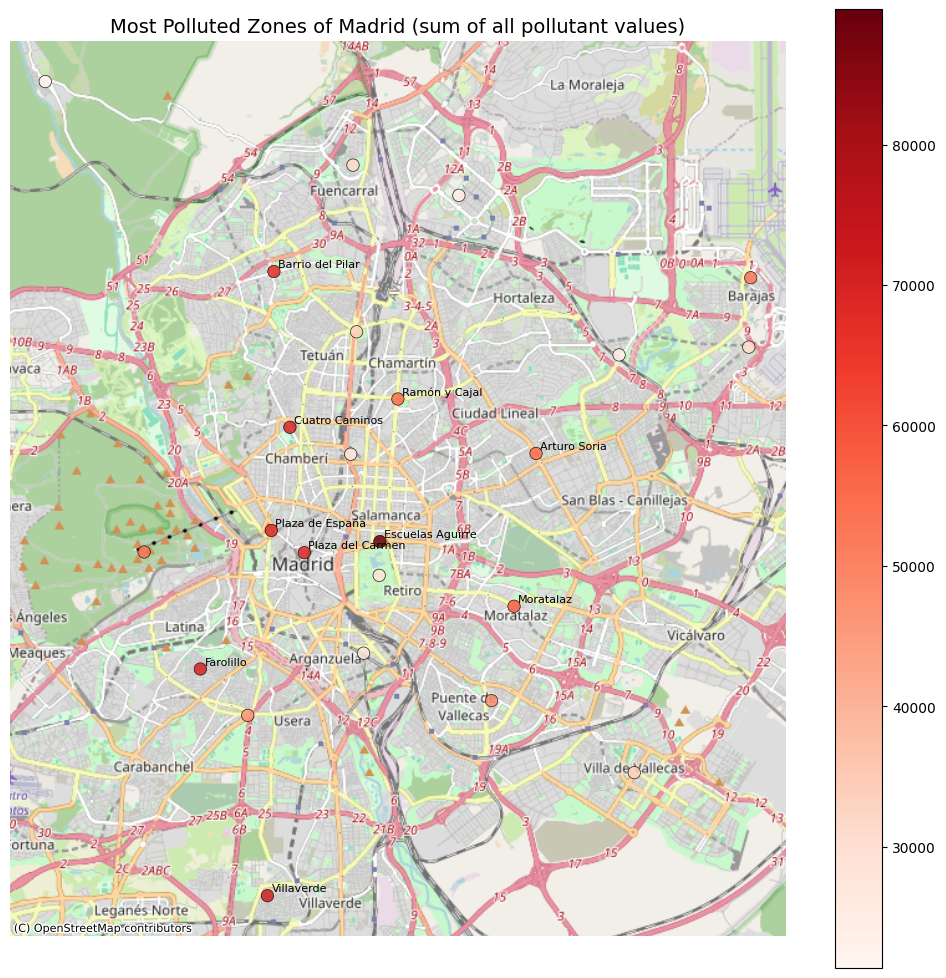

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_web.plot(
    ax=ax,
    column="total_pollution",
    cmap="Reds",
    legend=True,
    markersize=80,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5
)

# Add labels only for the top 10 most polluted
top10 = gdf_web.nlargest(10, "total_pollution")
for _, row in top10.iterrows():
    ax.annotate(
        text=str(row["sensor_name"]),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Most Polluted Zones of Madrid (sum of all pollutant values)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()



### 1.5)  initial time-series and distribution plots 📉

We now analyze the evolution of air pollution over time. The data is aggregated on a monthly basis by summing all pollutant values, resulting in the total pollution per month. We visualize this trend using a line plot, which shows how overall pollution levels have changed over time. This representation helps identify temporal patterns, trends, and potential peaks in pollution levels across the years.

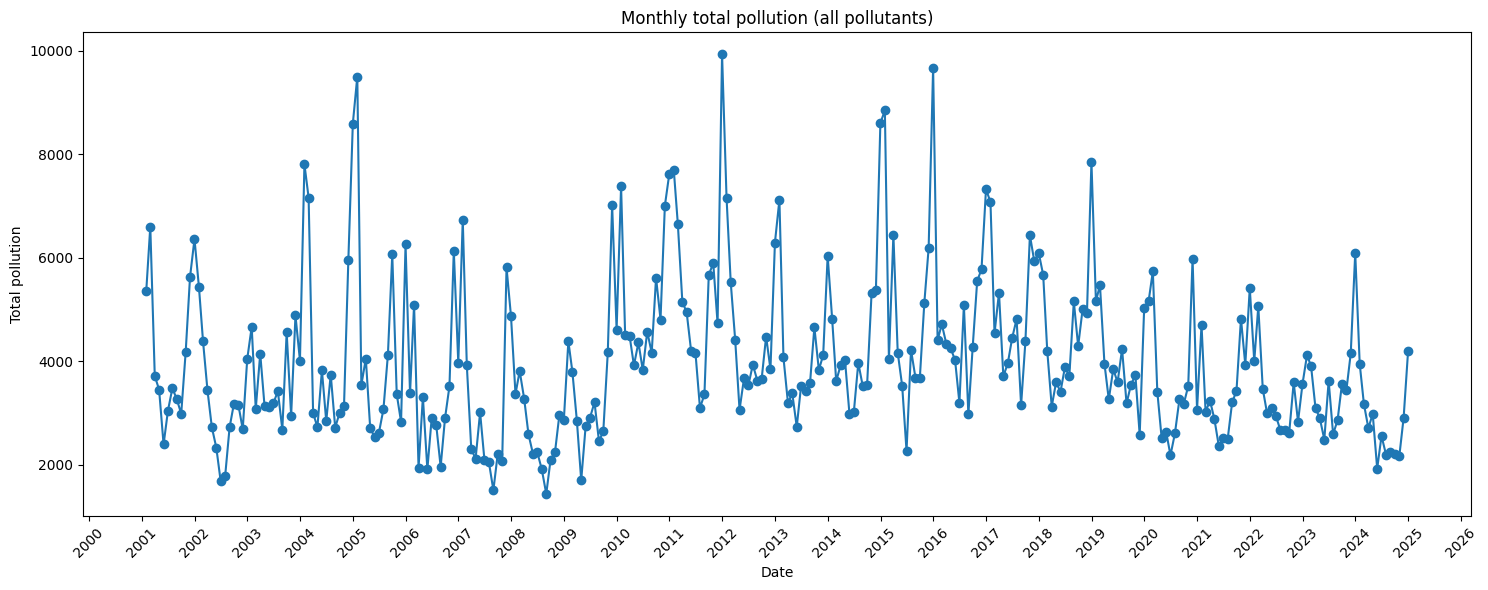

In [110]:
# copy data
df_ts = df_pollutants.copy()

# ensure datetime
df_ts["entry_date"] = pd.to_datetime(df_ts["entry_date"], errors="coerce")
df_ts = df_ts.dropna(subset=["entry_date"])

# set as index
df_ts = df_ts.set_index("entry_date")

# monthly aggregation
monthly_total = (
    df_ts["value"]
    .resample("ME")
    .sum()
    .reset_index())

# plot
plt.figure(figsize=(15, 6))
plt.plot(monthly_total["entry_date"], monthly_total["value"], marker="o")

plt.title("Monthly total pollution (all pollutants)")
plt.xlabel("Date")
plt.ylabel("Total pollution")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We now analyze the evolution of the weather over time. The data is aggregated on a monthly basis by summing all weather values, resulting in the total weather per month. We visualize this trend using a line plot, which shows how overall pollution levels have changed over time. This representation helps identify temporal patterns, trends, and potential peaks in weather levels across the years.

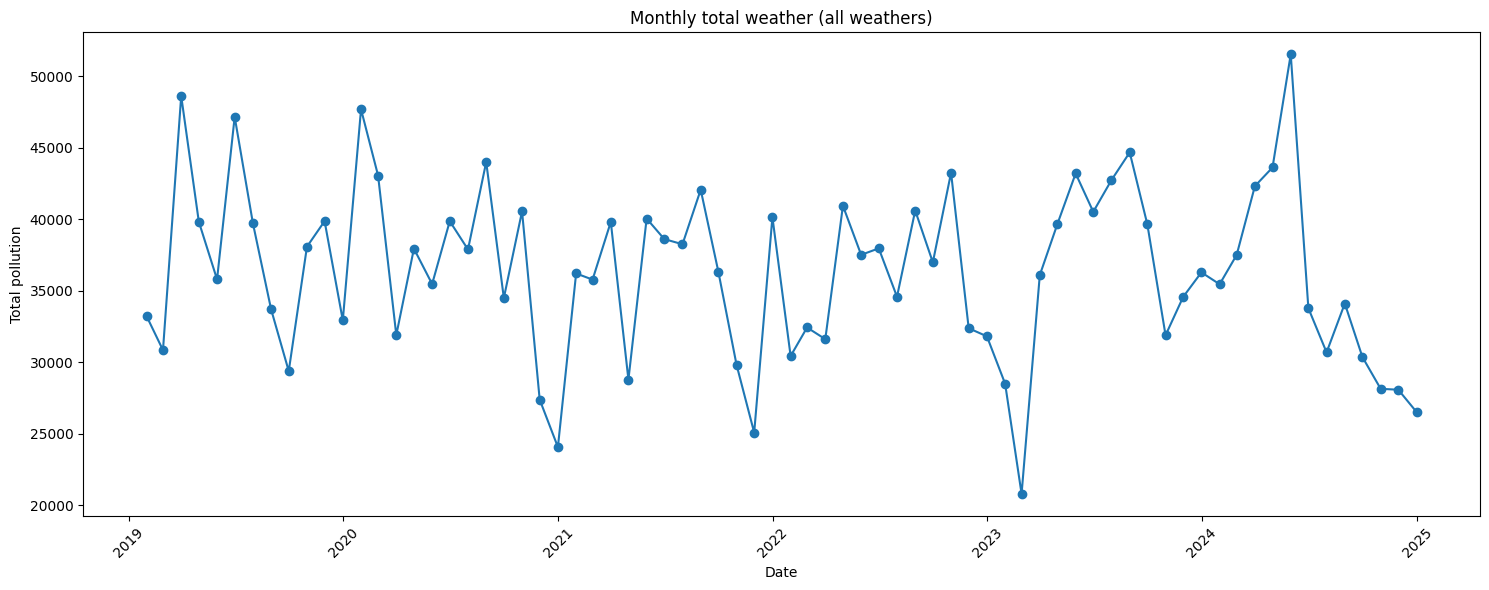

In [111]:
# copy data
df_ws = df_weather.copy()

# ensure datetime
df_ws["entry_date"] = pd.to_datetime(df_ws["entry_date"], errors="coerce")
df_ws = df_ws.dropna(subset=["entry_date"])

# set as index
df_ws = df_ws.set_index("entry_date")

# monthly aggregation 
monthly_total_w = (
    df_ws["value"]
    .resample("ME")
    .sum()
    .reset_index()
)

# plot
plt.figure(figsize=(15, 6))
plt.plot(monthly_total_w["entry_date"], monthly_total_w["value"], marker="o")

plt.title("Monthly total weather (all weathers)")
plt.xlabel("Date")
plt.ylabel("Total pollution")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We now analyze the evolution of the traffic over time. The data is aggregated on a monthly basis by summing all traffic values, resulting in the total traffic per month. We visualize this trend using a line plot, which shows how overall pollution levels have changed over time. This representation helps identify temporal patterns, trends, and potential peaks in traffic levels across the years.

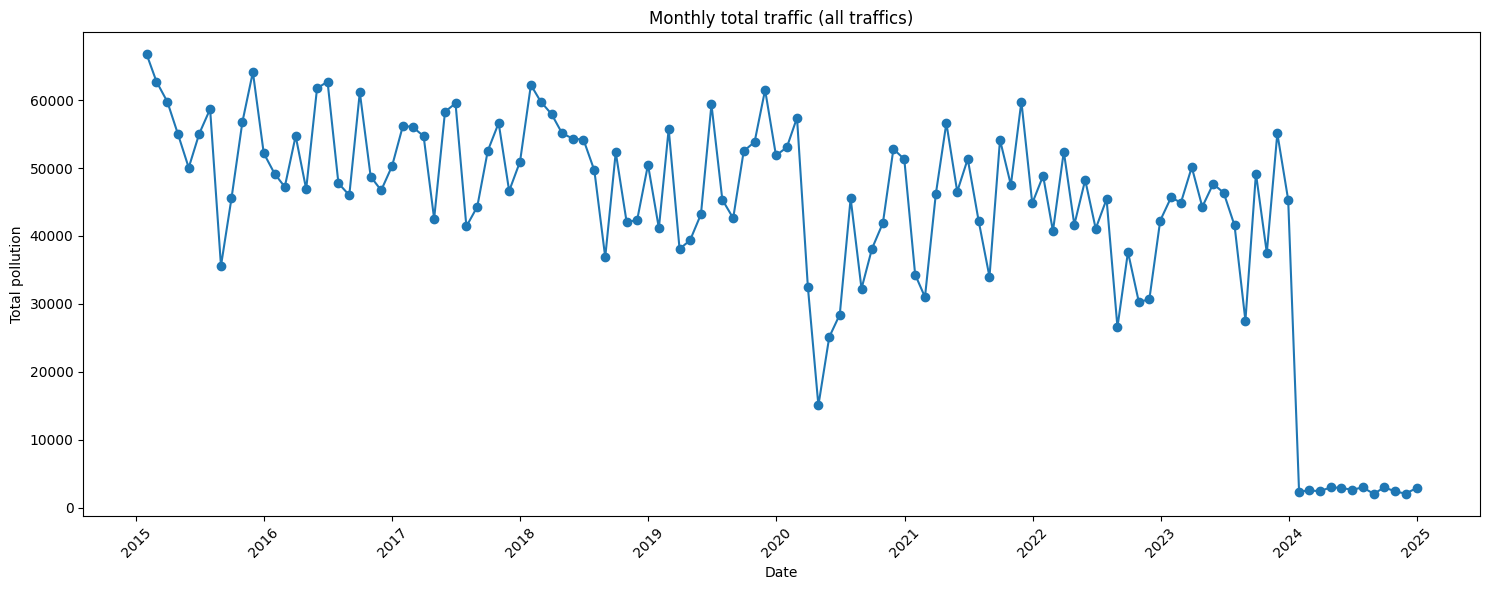

In [112]:
# copy data
df_tr = df_traffic.copy()

# ensure datetime
df_tr["entry_date"] = pd.to_datetime(df_tr["entry_date"], errors="coerce")
df_tr = df_tr.dropna(subset=["entry_date"])

# set as index
df_tr = df_tr.set_index("entry_date")

# monthly aggregation
monthly_total_t = (
    df_tr["value"]
    .resample("ME")
    .sum()
    .reset_index()
)

# plot
plt.figure(figsize=(15, 6))
plt.plot(monthly_total_t["entry_date"], monthly_total_t["value"], marker="o")

plt.title("Monthly total traffic (all traffics)")
plt.xlabel("Date")
plt.ylabel("Total pollution")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()